# AFQMC for the Hubbard model: a minimal, fully worked example

**Goal.** Set up the simplest possible interacting-lattice AFQMC calculation end to end:

1. define the Hubbard Hamiltonian and solve it exactly by hand,
2. build a **PySCF** mean-field (Hartree–Fock) object for it,
3. hand that mean field to **`afqmc`** and propagate in imaginary time with three different
   propagators — **free projection**, **phaseless**, and **constrained path** —
4. and watch the energy $E(\tau)$ decay to the ground state.

The starting system is *one electron on two sites*. There is no interaction energy to speak of
(a single electron can never doubly occupy a site), so Hartree–Fock is **exact** and every QMC
flavour must reproduce it to machine precision. That makes it the ideal unit test for the machinery.
We then move to genuinely correlated cases (the half-filled dimer, and a 4-site chain) where the
different propagators actually have something to do.

**Codes used**

| package | path | role |
|---|---|---|
| `pyscf` | `/home/sharmagroup/sharmagroup/pyscf` | mean field, FCI reference |
| `afqmc` | `/home/sharmagroup/sharmagroup/afqmc_lab/afqmc` | AFQMC propagators + samplers |
| `trot`  | `/home/sharmagroup/sharmagroup/trot_lab/trot` | discrete-HS **CPMC** (used at the end) |

## 0. Setup

In [1]:
import os, sys, time
from functools import partial

import numpy as np
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt

from pyscf import gto, scf, ao2mo, fci

# afqmc's config turns on float64 in jax and selects the CPU/GPU backend.
# It must be called before any heavy jax work.
from afqmc import config as afqmc_config
afqmc_config.setup_jax()

import jax
import jax.numpy as jnp
from jax import jit, random

from afqmc import prep, propagation, sampling, fp_sampling, linalg_utils
from afqmc.wavefunctions import wavefunctions_unrestricted as uwf

# trot is not installed as a package in this environment; add it to the path
TROT_PATH = "/home/sharmagroup/sharmagroup/trot_lab/trot"
if TROT_PATH not in sys.path:
    sys.path.insert(0, TROT_PATH)

np.set_printoptions(precision=8, suppress=True)
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})
print("jax devices:", jax.devices())

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      7.0.0-30-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu
jax devices: [CudaDevice(id=0)]


## 1. The Hubbard model and its exact solution on two sites

The single-band Hubbard Hamiltonian on a lattice of $N_s$ sites is

$$
\hat H \;=\; \underbrace{-t\!\!\sum_{\langle ij\rangle,\sigma}\!\big(\hat c^{\dagger}_{i\sigma}\hat c_{j\sigma}+\text{h.c.}\big)}_{\hat H_1\ \text{(hopping)}}
\;+\;\underbrace{U\sum_{i}\hat n_{i\uparrow}\hat n_{i\downarrow}}_{\hat H_2\ \text{(on-site repulsion)}} ,
\qquad \hat n_{i\sigma}=\hat c^{\dagger}_{i\sigma}\hat c_{i\sigma}.
$$

In quantum-chemistry language the "atomic orbitals" are the lattice sites. They are **orthonormal**,
so the overlap matrix is the identity, the core Hamiltonian is the hopping matrix

$$ (h_1)_{ij} = -t\,\delta_{\langle ij\rangle}, $$

and the two-electron integrals in chemist notation are purely local,

$$ (ij|kl) \;=\; U\,\delta_{ij}\delta_{jk}\delta_{kl}. $$

### The two-site, one-electron problem

With a single electron $\hat H_2$ can never act ($\hat n_{i\uparrow}\hat n_{i\downarrow}|\Phi\rangle=0$),
so the problem collapses to diagonalising the $2\times 2$ hopping matrix

$$
h_1=\begin{pmatrix}0&-t\\-t&0\end{pmatrix},
\qquad
|{\rm b}\rangle=\tfrac{1}{\sqrt2}\big(|1\rangle+|2\rangle\big),\ \ E_{\rm b}=-t,
\qquad
|{\rm a}\rangle=\tfrac{1}{\sqrt2}\big(|1\rangle-|2\rangle\big),\ \ E_{\rm a}=+t .
$$

The exact ground state is the bonding orbital with $E_0=-t$, **independent of $U$**.
A single Slater determinant represents it exactly, so RHF/UHF is exact and so is any correct QMC.

In [26]:
def hubbard_h1(n_sites, t, pbc=False):
    "Nearest-neighbour hopping matrix of an open (or periodic) chain."
    h1 = np.zeros((n_sites, n_sites))
    for i in range(n_sites - 1):
        h1[i, i + 1] = h1[i + 1, i] = -t
    if pbc and n_sites > 2:
        h1[0, -1] = h1[-1, 0] = -t
    return h1

def hubbard_eri(n_sites, u):
    "On-site two-electron integrals (ii|ii) = U in chemist notation."
    eri = np.zeros((n_sites,) * 4)
    for i in range(n_sites):
        eri[i, i, i, i] = u
    return eri

In [32]:
T_HOP  = 1.0     # hopping t
U_INT  = 4.0     # on-site repulsion U
N_SITES = 2

h1_dimer = hubbard_h1(N_SITES, T_HOP, pbc=True)
evals, evecs = np.linalg.eigh(h1_dimer)
evecs = evecs * np.sign(evecs[0])          # fix an arbitrary overall sign for display
print("hopping matrix h1 =\n", h1_dimer)
print("\none-particle levels :", evals)
print(f"bonding orbital = {evecs[:, 0]}")
print(f"exact (mf) ground-state energy of 1 electron on {N_SITES} sites  E0 = {evals[0]:.8f}")

hopping matrix h1 =
 [[ 0. -1.]
 [-1.  0.]]

one-particle levels : [-1.  1.]
bonding orbital = [0.70710678 0.70710678]
exact (mf) ground-state energy of 1 electron on 2 sites  E0 = -1.00000000


## 2. The mean field: a Hubbard model inside PySCF

PySCF has no notion of a lattice, but it never needs one: an SCF object only ever asks the
molecule for `get_hcore`, `get_ovlp` and `_eri`. If we override those three we can run the full
SCF/FCI machinery on any model Hamiltonian. This is exactly the recipe used in
`pyscf/examples/scf/72-hubbard_finite_temp.py`.

* `mol.nelectron`, `mol.nao`, `mol.spin` fix the Hilbert space,
* `mol.incore_anyway = True` forces PySCF to use the `_eri` array we supply,
* `get_ovlp = I` says the site basis is orthonormal.

We use **UHF** throughout, because AFQMC walkers here carry independent $\alpha$ and $\beta$
determinants, and because for the correlated cases below the broken-symmetry UHF determinant is
the natural trial function.

In [33]:
def hubbard_mf(n_sites, t, u, nelec, dm0=None, pbc=False):
    """
    Build a PySCF UHF object for a Hubbard chain.

    Returns (h1, eri, mol, mf).  `nelec` is (n_alpha, n_beta).
    """
    h1  = hubbard_h1(n_sites, t, pbc)
    eri = hubbard_eri(n_sites, u)

    mol = gto.M()
    mol.nelectron     = sum(nelec)
    mol.nao           = n_sites
    mol.spin          = nelec[0] - nelec[1]     # n_alpha - n_beta
    mol.incore_anyway = True
    mol.verbose       = 4
    mol.build()

    mf = scf.UHF(mol)
    mf.get_hcore = lambda *args: h1              # kinetic + external -> hopping
    mf.get_ovlp  = lambda *args: np.eye(n_sites) # sites are orthonormal
    mf._eri      = ao2mo.restore(8, eri, n_sites)
    mf.conv_tol  = 1e-12
    mf.max_cycle = 200
    mf.verbose   = 4
    mf.kernel(dm0=dm0)
    return h1, eri, mol, mf

In [34]:
# ---- one electron on two sites -------------------------------------------------
NELEC_A = (1, 0)                      # fully spin polarised: 1 alpha electron

dm0 = np.zeros((2, N_SITES, N_SITES)) # break the site symmetry to help SCF start
dm0[0, 0, 0] = 1.0

h1_A, eri_A, mol_A, mf_A = hubbard_mf(N_SITES, T_HOP, U_INT, NELEC_A, dm0=dm0)

print("E(UHF)   = %.12f" % mf_A.e_tot)
print("E(exact) = %.12f" % (-T_HOP))
print("error    = %.2e" % abs(mf_A.e_tot + T_HOP))
print("\nalpha MO coefficients (columns = orbitals, rows = sites):\n", mf_A.mo_coeff[0])
print("alpha occupations:", mf_A.mo_occ[0])



******** 1 electron system ********

WARN: HOMO -1 >= LUMO -1

converged SCF energy = -1  <S^2> = 0.75  2S+1 = 2
E(UHF)   = -1.000000000000
E(exact) = -1.000000000000
error    = 0.00e+00

alpha MO coefficients (columns = orbitals, rows = sites):
 [[ 0.70710678  0.70710678]
 [ 0.70710678 -0.70710678]]
alpha occupations: [1. 0.]


In [38]:
mf_A.mo_coeff[0]

array([[ 0.70710678,  0.70710678],
       [ 0.70710678, -0.70710678]])

The SCF converges to $-t$ and the occupied orbital is the bonding combination
$\tfrac{1}{\sqrt2}(1,1)$, exactly as predicted. The value of $U$ is irrelevant here — a good
first sanity check that the integrals were handed over correctly.

## 3. From the Hubbard interaction to auxiliary fields

AFQMC computes the ground state by imaginary-time projection,

$$
|\Psi_0\rangle \;\propto\; \lim_{\tau\to\infty} e^{-\tau\hat H}\,|\Phi_0\rangle ,
\qquad
e^{-\tau\hat H}=\Big(e^{-\Delta\tau \hat H}\Big)^{\tau/\Delta\tau},
$$

with the symmetric Trotter split

$$
e^{-\Delta\tau\hat H}\;\simeq\;
e^{-\frac{\Delta\tau}{2}\hat H_1}\;
e^{-\Delta\tau\hat H_2}\;
e^{-\frac{\Delta\tau}{2}\hat H_1}\;+\;\mathcal O(\Delta\tau^{3}).
$$

The one-body factors map a Slater determinant onto another Slater determinant (Thouless theorem).
The two-body factor does not — that is what the Hubbard–Stratonovich (HS) transformation fixes.

### 3.1 The general form used by `afqmc`

`afqmc` (like all Cholesky-based AFQMC codes) writes the two-body Hamiltonian with a set of
one-body operators $\hat L_\gamma=\sum_{ij\sigma}L^{\gamma}_{\sigma,ij}\hat c^\dagger_{i\sigma}\hat c_{j\sigma}$:

$$
\hat H_2=\tfrac12\sum_\gamma \hat L_\gamma^{\,2}\;-\;\hat v_0,
\qquad
(v_0)_{ij}=\tfrac12\sum_\gamma\big(L^{\gamma}L^{\gamma}\big)_{ij},
$$

the $\hat v_0$ piece being the one-body remainder from normal ordering. It is absorbed into the
modified one-body Hamiltonian `exp_h1` $=e^{-\frac{\Delta\tau}{2}(h_1-v_0-v_1)}$ (the $v_1$ term
is the mean-field subtraction, section 5). The HS identity then turns each square into a Gaussian
integral over an auxiliary field $x_\gamma$:

$$
\boxed{\;
e^{-\frac{\Delta\tau}{2}\hat L_\gamma^{2}}
=\frac{1}{\sqrt{2\pi}}\int\! dx\;e^{-x^{2}/2}\;e^{\,i\sqrt{\Delta\tau}\,x\,\hat L_\gamma}\;}
$$

which is exactly the line `vhs = 1j*sqrt(dt)*fields.dot(chol)` in `afqmc/propagation.py`.
In the code `ham_data["chol"]` is a **tuple** $(L^\gamma_\uparrow, L^\gamma_\downarrow)$ — the
$\alpha$ and $\beta$ one-body matrices may be different. That freedom is precisely what we need.

### 3.2 Two ways to decompose $U\hat n_\uparrow\hat n_\downarrow$

Because $\hat n_{i\sigma}^2=\hat n_{i\sigma}$, the on-site repulsion can be written as a square in
two inequivalent ways.

**(a) Charge decomposition.** Using $\hat n_i^2=\hat n_i+2\hat n_{i\uparrow}\hat n_{i\downarrow}$ with
$\hat n_i = \hat n_{i\uparrow}+\hat n_{i\downarrow}$,

$$
U\,\hat n_{i\uparrow}\hat n_{i\downarrow}=\tfrac{U}{2}\hat n_i^{2}-\tfrac{U}{2}\hat n_i
\quad\Longrightarrow\quad
L^{\gamma}_{\uparrow}=L^{\gamma}_{\downarrow}=\sqrt{U}\,|\gamma\rangle\langle\gamma| .
$$

Then $\hat L_\gamma=\sqrt{U}\,\hat n_\gamma$ is Hermitian and *real*, so the field operator
$e^{\,i\sqrt{\Delta\tau U}\,x\,\hat n_\gamma}$ is a **complex phase**. Walkers become complex:
this is the origin of the *phase* problem.

**(b) Spin decomposition.** Using $(\hat n_{i\uparrow}-\hat n_{i\downarrow})^2=\hat n_i-2\hat n_{i\uparrow}\hat n_{i\downarrow}$,

$$
U\,\hat n_{i\uparrow}\hat n_{i\downarrow}=-\tfrac{U}{2}\big(\hat n_{i\uparrow}-\hat n_{i\downarrow}\big)^{2}+\tfrac{U}{2}\hat n_i
\quad\Longrightarrow\quad
L^{\gamma}_{\uparrow}=-i\sqrt{U}\,|\gamma\rangle\langle\gamma|,\qquad
L^{\gamma}_{\downarrow}=+i\sqrt{U}\,|\gamma\rangle\langle\gamma| .
$$

Now $\hat L_\gamma=-i\sqrt{U}(\hat n_{\gamma\uparrow}-\hat n_{\gamma\downarrow})$ is
*anti*-Hermitian, so

$$
e^{\,i\sqrt{\Delta\tau}\,x\,\hat L_\gamma}
= e^{\,\sqrt{\Delta\tau U}\;x\,(\hat n_{\gamma\uparrow}-\hat n_{\gamma\downarrow})}
$$

is **real and positive**. Real walkers stay real forever. There is no phase — only a possible
change of *sign* of the overlap $\langle\Psi_T|\phi\rangle$. This is the standard statement that
the repulsive Hubbard model has a *sign* problem, not a *phase* problem, and it is the
decomposition we use below.

Let us check that (b) really reproduces $\hat H_2$. With $L^\gamma_\uparrow=-i\sqrt U|\gamma\rangle\langle\gamma|$,

$$
\tfrac12\sum_\gamma\hat L^2_\gamma
=-\tfrac{U}{2}\sum_\gamma(\hat n_{\gamma\uparrow}-\hat n_{\gamma\downarrow})^2
=-\tfrac{U}{2}\sum_\gamma\hat n_\gamma+U\sum_\gamma\hat n_{\gamma\uparrow}\hat n_{\gamma\downarrow},
\qquad
\hat v_0=-\tfrac{U}{2}\sum_\gamma\hat n_\gamma ,
$$

so $\tfrac12\sum_\gamma \hat L_\gamma^2-\hat v_0 = U\sum_\gamma \hat n_{\gamma\uparrow}\hat n_{\gamma\downarrow}$. ✔

In [40]:
def spin_chol(n_sites, u):
    """
    Spin (Hirsch) decomposition:  L^g_up = -i sqrt(U) |g><g| ,  L^g_dn = +i sqrt(U) |g><g|
    -> the auxiliary-field propagator exp(i sqrt(dt) x L) is REAL.
    """
    d = np.zeros((n_sites, n_sites, n_sites), dtype=complex)
    for g in range(n_sites):
        d[g, g, g] = 1.0
    return jnp.array(-1j * np.sqrt(u) * d), jnp.array(+1j * np.sqrt(u) * d)

def charge_chol(n_sites, u):
    """
    Charge decomposition:  L^g_up = L^g_dn = sqrt(U) |g><g|
    -> the propagator exp(i sqrt(dt) x L) is a complex PHASE.
    """
    d = np.zeros((n_sites, n_sites, n_sites), dtype=complex)
    for g in range(n_sites):
        d[g, g, g] = 1.0
    return jnp.array(np.sqrt(u) * d), jnp.array(np.sqrt(u) * d)

ca, cb = spin_chol(N_SITES, U_INT)
print("number of auxiliary fields (Cholesky vectors) =", ca.shape[0])
print("L^0_up =\n", np.array(ca[0]))
print("L^0_dn =\n", np.array(cb[0]))

number of auxiliary fields (Cholesky vectors) = 2
L^0_up =
 [[0.-2.j 0.+0.j]
 [0.+0.j 0.+0.j]]
L^0_dn =
 [[0.+2.j 0.+0.j]
 [0.+0.j 0.+0.j]]


## 4. Assembling the `afqmc` objects

The pieces `afqmc` needs are

| object | what it is | built by |
|---|---|---|
| `ham_data` | `h0`, `h1` (per spin), `chol` (per spin) and derived intermediates | `prep.get_hamiltonian` |
| `trial`    | the trial wave function handler (here `uhf`) | `wavefunctions_unrestricted.uhf` |
| `wave_data`| `mo_coeff` (occupied orbitals per spin) and `rdm1` | from the PySCF `mf` |
| `prop`     | the propagator (time step, walker count, Trotter order) | `propagation.propagator_*` |
| `sampler`  | the imaginary-time loop and the energy estimator | `sampling.sampler`, `fp_sampling.fp_sampler` |

`build_measurement_intermediates` half-rotates the integrals with the trial
($\tilde h_1 = C^\dagger h_1$, $\tilde L^\gamma = C^\dagger L^\gamma$) so that the local energy
can be evaluated from the half Green's function
$G_\sigma=\phi_\sigma\big(C_\sigma^\dagger\phi_\sigma\big)^{-1}$.
`build_propagation_intermediates` computes the mean-field shift, `h0_prop` and `exp_h1`.

Note that we stay in the **site basis** the whole time: the trial orbitals are the PySCF MO
coefficients, and the walkers are $N_s\times N_\sigma$ matrices of site amplitudes.

In [41]:
def afqmc_setup(h1, u, nelec, mo_a, mo_b, n_sites, decomposition="spin", h0=0.0):
    """
    Package a Hubbard model + a UHF trial into the objects the afqmc package expects.
    """
    chol = spin_chol(n_sites, u) if decomposition == "spin" else charge_chol(n_sites, u)

    ham, ham_data, nchol = prep.get_hamiltonian(h0, (h1, h1), chol, n_sites)

    trial = uwf.uhf(n_sites, tuple(nelec), nchol_chunk=100, n_batch=1)
    wave_data = {"mo_coeff": [jnp.array(mo_a), jnp.array(mo_b)]}
    wave_data["rdm1"] = trial.get_rdm1(wave_data)          # (2, norb, norb)

    ham_data = ham.build_measurement_intermediates(ham_data, trial, wave_data)
    return ham, ham_data, nchol, trial, wave_data


ham_A, hamdata_A, nchol_A, trial_A, wave_A = afqmc_setup(
    h1_A, U_INT, NELEC_A, mf_A.mo_coeff[0][:, :NELEC_A[0]],
                          mf_A.mo_coeff[1][:, :NELEC_A[1]], N_SITES)

print("nchol      :", nchol_A)
print("h1  (alpha):\n", np.array(hamdata_A["h1"][0]))
print("rdm1(alpha):\n", np.array(wave_A["rdm1"][0]))
print("rdm1(beta) :\n", np.array(wave_A["rdm1"][1]))

nchol      : 2
h1  (alpha):
 [[ 0. -1.]
 [-1.  0.]]
rdm1(alpha):
 [[0.5 0.5]
 [0.5 0.5]]
rdm1(beta) :
 [[0. 0.]
 [0. 0.]]


E0903 20:42:56.815690  821485 cuda_executor.cc:1213] [0] Failed to track device allocation: ALREADY_EXISTS: Allocation at address (nil) (size 0) is already tracked


In [15]:
# Local energy of the trial determinant itself must reproduce the SCF energy.
prop_check = propagation.propagator_unrestricted(dt=0.01, n_walkers=4, n_exp_terms=6, n_batch=1)
hd_check   = ham_A.build_propagation_intermediates(dict(hamdata_A), prop_check, trial_A, wave_A)
pd_check   = prop_check.init_prop_data(trial_A, wave_A, hd_check, None)

print("mean-field shifts  <L_g>  :", np.array(hd_check["mf_shifts"]))
print("h0_prop                   :", complex(hd_check["h0_prop"]))
print("exp(-dt/2 h1_mod) alpha   :\n", np.array(hd_check["exp_h1"][0]))
print()
print("AFQMC local energy of the HF determinant : %.12f" % float(pd_check["e_estimate"]))
print("PySCF UHF energy                        : %.12f" % mf_A.e_tot)

mean-field shifts  <L_g>  : [1.+0.j 1.+0.j]
h0_prop                   : (-0.9999999999999996+0j)
exp(-dt/2 h1_mod) alpha   :
 [[1.0000125 +0.j 0.00500002+0.j]
 [0.00500002+0.j 1.0000125 +0.j]]

AFQMC local energy of the HF determinant : -1.000000000000
PySCF UHF energy                        : -1.000000000000


The mean-field shifts are **real** (they would be purely imaginary for the charge decomposition),
`exp_h1` is real, and the local energy of the trial determinant reproduces the SCF energy exactly.
The Hamiltonian has been handed over correctly.

## 5. The three propagators

Write one propagation step for a walker $|\phi\rangle$ with weight $W$ as

$$
|\phi'\rangle=\hat B(\mathbf{x}-\bar{\mathbf{x}})\,|\phi\rangle,\qquad
\hat B(\mathbf{x})=e^{-\frac{\Delta\tau}{2}\hat h_1}\,e^{\,i\sqrt{\Delta\tau}\,\mathbf{x}\cdot\hat{\mathbf L}}\,e^{-\frac{\Delta\tau}{2}\hat h_1}.
$$

Two shifts of the Gaussian variable are used:

* the **mean-field (background) subtraction** $m_\gamma=i\langle\hat L_\gamma\rangle_{\Psi_T}$,
  which removes the large one-body part of $\hat L_\gamma$ (`ham_data["mf_shifts"]`);
* the **force bias** $\bar x_\gamma = -\sqrt{\Delta\tau}\,\big(i\,\langle \hat L_\gamma\rangle_{\rm mix}-m_\gamma\big)$,
  with $\langle\hat L_\gamma\rangle_{\rm mix}=\langle\Psi_T|\hat L_\gamma|\phi\rangle/\langle\Psi_T|\phi\rangle$,
  which is *importance sampling*: it steers the fields towards regions with large overlap.

Shifting the Gaussian is exact provided the weight is multiplied by the **importance function**

$$
I(\mathbf x,\bar{\mathbf x},\phi)=
\frac{\langle\Psi_T|\phi'\rangle}{\langle\Psi_T|\phi\rangle}\;
\exp\!\Big[\underbrace{\mathbf x\!\cdot\!\bar{\mathbf x}-\tfrac12\bar{\mathbf x}\!\cdot\!\bar{\mathbf x}}_{\text{force-bias Jacobian}}
\;\underbrace{-\sqrt{\Delta\tau}\,(\mathbf x-\bar{\mathbf x})\!\cdot\!\mathbf m}_{\text{background}}
\;+\;\Delta\tau\,(E_S+h_0')\Big].
$$

This is literally the block of code in `propagator.propagate`. The three algorithms differ **only**
in what they do with $I$:

| algorithm | weight update | bias |
|---|---|---|
| **free projection** | no force bias, no constraint; $W\leftarrow W\,\lVert\cdot\rVert$, the sign/phase is carried in the walker | none — *exact* |
| **phaseless** | $W\leftarrow W\;\lvert I\rvert\;\max\!\big(0,\cos\theta\big)$, $\ \theta=\arg\!\big[\tfrac{\langle\Psi_T|\phi'\rangle}{\langle\Psi_T|\phi\rangle}e^{-\sqrt{\Delta\tau}(\mathbf x-\bar{\mathbf x})\cdot\mathbf m}\big]$ | phaseless approximation |
| **constrained path** | $W\leftarrow W\;\max\!\big(0,\ \mathrm{Re}\,I\big)$ | constrained-path approximation |

**The key identity.** If the propagator is real (spin decomposition) and the trial is real, then
$I\in\mathbb{R}$, hence $\theta\in\{0,\pi\}$ and

$$
|I|\max(0,\cos\theta)\;=\;\max\big(0,\mathrm{Re}\,I\big).
$$

So on the Hubbard model with the spin decomposition, phaseless **is** constrained path — they are
the same algorithm written two ways. We verify this numerically below.

### What `afqmc` provides and what it does not

* `propagation.propagator_unrestricted.propagate` — the **phaseless** update. Used as is.
* `propagation.propagator_unrestricted.propagate_free` + `fp_sampling.fp_sampler` — **free projection**.
  These divide by `2*nelec[sigma]` when re-attaching the accumulated phase to the orbitals, which
  raises `ZeroDivisionError` for a fully polarised system such as ours ($n_\beta=0$). We subclass
  and distribute the phase over *all* $N_e$ occupied columns instead, which is equivalent whenever
  both channels are occupied. (We also fix a stray parenthesis, `dt*(h0_prop) + e_estimate`
  instead of `dt*(h0_prop + e_estimate)`; it is a walker-independent constant and cancels in the
  estimator, but it can overflow.)
* **constrained path** is not available for this continuous-field propagator (`propagator_cpmc`
  exists but requires trial methods `calc_full_green_vmap` / `calc_overlap_ratio_vmap` /
  `update_greens_function_vmap` that are not implemented in `afqmc/wavefunctions`). We add a
  10-line subclass. In section 12 we cross-check against **`trot`**, which does have a complete
  discrete-HS CPMC implementation.

In [42]:
class propagator_uhf_gen(propagation.propagator_unrestricted):
    """
    Unrestricted phaseless propagator + a free-projection step that also works when one
    spin channel is empty.

    The accumulated phase must be absorbed into the walker so that the overlap picks up
    exactly one factor of `phase`.  Multiplying every occupied column of both determinants
    by c gives det factor c^(n_up) * c^(n_dn) = c^(N_e), so c = phase**(1/N_e).
    """

    @partial(jit, static_argnums=(0, 1))
    def propagate_free(self, trial, ham_data, prop_data, fields):
        n_tot = trial.nelec[0] + trial.nelec[1]

        # background (mean-field) subtraction only -- no force bias, no constraint
        shift_term = jnp.einsum("wg,g->w", fields, ham_data["mf_shifts"])
        constants  = jnp.exp(-jnp.sqrt(self.dt) * shift_term) * jnp.exp(
            self.dt * (ham_data["h0_prop"] + prop_data["e_estimate"]))

        constants_abs = jnp.abs(constants)
        phase         = constants / constants_abs

        prop_data["weights"] = prop_data["weights"] * constants_abs
        prop_data["walkers"] = self._apply_trotprop(ham_data, prop_data["walkers"], fields)

        c = phase ** (1.0 / n_tot)
        prop_data["walkers"] = self._multiply_constant(prop_data["walkers"], jnp.stack((c, c)))
        return prop_data


class propagator_cp(propagator_uhf_gen):
    """
    Constrained-path propagator.

    Identical to the phaseless `propagate` except for the last step:
        phaseless :  W <- W * |I| * cos(theta)
        CP        :  W <- W * max(0, Re I)
    """

    @partial(jit, static_argnums=(0, 1))
    def propagate(self, trial, ham_data, prop_data, fields, wave_data):
        force_bias   = trial.calc_force_bias(prop_data["walkers"], ham_data, wave_data)
        field_shifts = -jnp.sqrt(self.dt) * (1.0j * force_bias - ham_data["mf_shifts"])
        shifted_fields = fields - field_shifts

        shift_term = jnp.sum(shifted_fields * ham_data["mf_shifts"], axis=1)
        fb_term    = jnp.sum(fields * field_shifts - field_shifts * field_shifts / 2.0, axis=1)

        prop_data["walkers"] = self._apply_trotprop(
            ham_data, prop_data["walkers"], shifted_fields)

        overlaps_new = trial.calc_overlap(prop_data["walkers"], wave_data)
        imp_fun = (
            jnp.exp(-jnp.sqrt(self.dt) * shift_term
                    + fb_term
                    + self.dt * (prop_data["pop_control_ene_shift"] + ham_data["h0_prop"]))
            * overlaps_new / prop_data["overlaps"]
        )

        # ---- the constrained-path condition ------------------------------------
        imp_fun_cp = jnp.real(imp_fun)
        imp_fun_cp = jnp.where(jnp.isnan(imp_fun_cp), 0.0, imp_fun_cp)
        imp_fun_cp = jnp.where(imp_fun_cp < 0.0,      0.0, imp_fun_cp)   # kill node crossers
        imp_fun_cp = jnp.where(imp_fun_cp > 100.0,    0.0, imp_fun_cp)
        # ------------------------------------------------------------------------

        prop_data["weights"] = imp_fun_cp * prop_data["weights"]
        prop_data["weights"] = jnp.where(prop_data["weights"] > 100, 0.0, prop_data["weights"])
        prop_data["pop_control_ene_shift"] = prop_data["e_estimate"] - 0.1 * jnp.array(
            jnp.log(jnp.sum(prop_data["weights"]) / self.n_walkers) / self.dt)
        prop_data["overlaps"] = overlaps_new
        return prop_data


class fp_sampler_gen(fp_sampling.fp_sampler):
    """`fp_sampler` with the same N_e-column phase redistribution (see above)."""

    @partial(jit, static_argnums=(0, 4, 5))
    def _step_scan(self, prop_data, fields, ham_data, prop, trial, wave_data):
        prop_data = prop.propagate_free(trial, ham_data, prop_data, fields)

        prop_data["walkers"], norms = linalg_utils.qr_vmap_uhf(prop_data["walkers"])
        norms     = norms[0] * norms[1]
        norms_abs = jnp.abs(norms)
        phase     = norms / norms_abs

        n_walkers = int(prop_data["weights"].shape[0])
        prop_data["weights"] = prop_data["weights"] * norms_abs
        prop_data["weights"] = n_walkers * prop_data["weights"] / jnp.sum(prop_data["weights"])

        n_tot = trial.nelec[0] + trial.nelec[1]
        c = phase ** (1.0 / n_tot)
        prop_data["walkers"] = prop._multiply_constant(prop_data["walkers"], jnp.stack((c, c)))

        prop_data = prop.stochastic_reconfiguration_local(prop_data)
        return prop_data, fields

print("propagators ready")

propagators ready


## 6. Drivers: energy as a function of imaginary time

Both drivers return $E(\tau)$ on a grid $\tau_n = n\,N_{\rm steps}\Delta\tau$.

**Free projection.** No constraint at all, so the estimator is the *mixed* estimator with the
overlap kept explicitly in the weight,

$$
E_{\rm FP}(\tau)=
\frac{\sum_w W_w\,\langle\Psi_T|\phi_w\rangle\;E_L[\phi_w]}
     {\sum_w W_w\,\langle\Psi_T|\phi_w\rangle},
\qquad
E_L[\phi]=\frac{\langle\Psi_T|\hat H|\phi\rangle}{\langle\Psi_T|\phi\rangle}.
$$

Averaging over many independent *trajectories* (rather than over blocks of one long walk) is what
`fp_sampler` does, because free-projection weights have no steady state — their variance grows
exponentially. That growth *is* the sign problem.

**Phaseless / constrained path.** Importance sampling folds $\langle\Psi_T|\phi_w\rangle$ into the
weight, so

$$
E(\tau)=\frac{\sum_w W_w E_L[\phi_w]}{\sum_w W_w},
$$

and the walk has a steady state, so we can average blocks along a single trajectory.

In [48]:
def run_free_projection(ham, ham_data, trial, wave_data, nchol,
                        dt=0.01, n_walkers=500, n_prop_steps=10, n_blocks=30,
                        n_traj=16, seed=0, n_exp_terms=10):
    "Free-projection AFQMC.  Returns tau, E(tau), stderr(tau)."
    prop = propagator_uhf_gen(dt=dt, n_walkers=n_walkers,
                              n_exp_terms=n_exp_terms, n_batch=1)
    hd   = ham.build_propagation_intermediates(dict(ham_data), prop, trial, wave_data)
    smp  = fp_sampler_gen(n_prop_steps=n_prop_steps, n_eql_blocks=n_blocks,
                          n_trj=n_traj, n_chol=nchol)

    ws, es = [], []
    for key in random.split(random.PRNGKey(seed), n_traj):
        pd = prop.init_prop_data(trial, wave_data, hd, None)
        pd["key"] = key
        pd, (blk_w, blk_e) = smp.scan_eql_blocks(pd, hd, prop, trial, wave_data)
        ws.append(np.asarray(blk_w)); es.append(np.asarray(blk_e))

    ws, es = np.array(ws).T, np.array(es).T           # (n_blocks, n_traj)
    mean = np.real(np.sum(ws * es, axis=1) / np.sum(ws, axis=1))
    err  = np.real(np.std(es, axis=1, ddof=1)) / np.sqrt(n_traj)
    tau  = dt * n_prop_steps * np.arange(1, n_blocks + 1)
    return tau, mean, err, pd


def run_constrained(prop_cls, ham, ham_data, trial, wave_data, nchol,
                    dt=0.01, n_walkers=500, n_prop_steps=10, n_blocks=30,
                    n_runs=6, seed=0, n_exp_terms=10):
    "Phaseless (prop_cls=propagator_uhf_gen) or CP (prop_cls=propagator_cp) AFQMC."
    prop = prop_cls(dt=dt, n_walkers=n_walkers, n_exp_terms=n_exp_terms, n_batch=1)
    hd   = ham.build_propagation_intermediates(dict(ham_data), prop, trial, wave_data)
    smp  = sampling.sampler(n_prop_steps=n_prop_steps, n_blocks=n_blocks, n_chol=nchol)

    all_e, n_killed = [], 0
    for key in random.split(random.PRNGKey(seed), n_runs):
        pd = prop.init_prop_data(trial, wave_data, hd, None)
        pd["key"] = key
        pd["n_killed_walkers"] = 0
        e_run = []
        for _ in range(n_blocks):
            pd, (wt, en, err) = smp.block_sample(pd, hd, prop, trial, wave_data)
            e_run.append(float(en))
        n_killed += int(pd["n_killed_walkers"])
        all_e.append(e_run)

    all_e = np.array(all_e)                            # (n_runs, n_blocks)
    tau   = dt * n_prop_steps * np.arange(1, n_blocks + 1)
    return tau, all_e.mean(0), all_e.std(0, ddof=1) / np.sqrt(n_runs), all_e, n_killed, pd

In [49]:
def plateau_estimate(raw, discard=0.5, n_seg=1):
    """
    Converged energy from a set of independent constrained trajectories.

    `raw` has shape (n_runs, n_blocks).  Block energies *within* one trajectory are strongly
    autocorrelated, so the naive std/sqrt(n_blocks) underestimates the error by a factor of
    a few.  We therefore average each trajectory (optionally split into `n_seg` long
    contiguous segments) and use the scatter of those means, which are independent.
    """
    n_runs, n_blocks = raw.shape
    tail  = raw[:, int(discard * n_blocks):]
    segs  = np.array_split(tail, n_seg, axis=1)
    means = np.concatenate([sg.mean(axis=1) for sg in segs])
    return means.mean(), means.std(ddof=1) / np.sqrt(means.size)


# --- exact references for two-site models -------------------------------------
def dimer_ci(t, u, nelec):
    """
    Full CI Hamiltonian of the 2-site Hubbard model in the determinant basis, plus a
    function mapping a Slater determinant (mo_a, mo_b) to its CI vector.
    """
    h = np.array([[0.0, -t], [-t, 0.0]])
    if nelec == (1, 0):
        H = h
        to_ci = lambda ca, cb: np.asarray(ca).ravel()
    elif nelec == (1, 1):
        # basis: |i_up j_dn>, i,j = 0,1  ->  (0,0), (0,1), (1,0), (1,1)
        H = np.kron(h, np.eye(2)) + np.kron(np.eye(2), h) + u * np.diag([1.0, 0.0, 0.0, 1.0])
        to_ci = lambda ca, cb: np.kron(np.asarray(ca).ravel(), np.asarray(cb).ravel())
    else:
        raise NotImplementedError
    return H, to_ci


def exact_mixed_estimator(H, v_trial, v_init, taus):
    r"""
    E_mix(tau) = <Psi_T| H e^{-tau H} |Phi_0> / <Psi_T| e^{-tau H} |Phi_0>
    -- the quantity AFQMC's mixed estimator converges to, evaluated exactly.
    """
    w, V = np.linalg.eigh(H)
    out = []
    for tau in taus:
        P = V @ np.diag(np.exp(-tau * w)) @ V.T
        out.append((v_trial @ H @ P @ v_init) / (v_trial @ P @ v_init))
    return np.array(out)

print("reference tools ready")

reference tools ready


## 7. The minimal example: 1 electron, 2 sites, exact trial

The HF determinant *is* the exact ground state, so

$$E_{\rm mix}(\tau)=\frac{\langle\Psi_0|\hat H e^{-\tau\hat H}|\Phi_0\rangle}{\langle\Psi_0|e^{-\tau\hat H}|\Phi_0\rangle}=E_0=-t
\qquad\text{for every }\tau\text{ and every walker.}$$

All three propagators must return a flat line at $-1$ with (essentially) zero variance. This is
the strongest possible test that the Cholesky vectors, the mean-field shift, the Trotter
propagator and the estimators are all mutually consistent.

In [50]:
t0 = time.time()
DT, NSTEP, NBLK = 0.01, 10, 20

tau_fp, e_fp, err_fp, pd = run_free_projection(
    ham_A, hamdata_A, trial_A, wave_A, nchol_A,
    dt=DT, n_walkers=500, n_prop_steps=NSTEP, n_blocks=NBLK, n_traj=1, seed=11)

print("           tau      E(tau)          |E + t|")
for i in [0, NBLK // 2, NBLK - 1]:
    print(f"free proj  {tau_fp[i]:5.2f}  {e_fp[i]:+.12f}  {abs(e_fp[i]+T_HOP):.2e}")
    print()

           tau      E(tau)          |E + t|
free proj   0.10  -1.000000000000  1.11e-16

free proj   1.10  -1.000000000000  0.00e+00

free proj   2.00  -1.000000000000  0.00e+00



/home/sharmagroup/miniconda3/envs/myafqmc/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/sharmagroup/miniconda3/envs/myafqmc/lib/python3.12/site-packages/numpy/_core/_methods.py:208: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


In [ ]:
DT, NSTEP, NBLK = 0.01, 10, 100

ham = ham_A; ham_data = hamdata_A; trial = trial_A; wave_data = wave_A; nchol = nchol_A
dt=DT; n_walkers=2000; n_prop_steps=NSTEP; n_blocks=NBLK; n_traj=1; seed=11

"Free-projection AFQMC.  Returns tau, E(tau), stderr(tau)."
prop = propagator_uhf_gen(dt=dt, n_walkers=n_walkers,
                            n_exp_terms=10, n_batch=1)
hd   = ham.build_propagation_intermediates(dict(ham_data), prop, trial, wave_data)
smp  = fp_sampler_gen(n_prop_steps=n_prop_steps, 
                      n_eql_blocks=n_blocks,
                      n_trj=n_traj, 
                      n_chol=nchol
                      )

ws, es = [], []
for key in random.split(random.PRNGKey(seed), n_traj):
    pd = prop.init_prop_data(trial, wave_data, hd, None)
    pd["key"] = key
    pd, (blk_w, blk_e) = smp.scan_eql_blocks(pd, hd, prop, trial, wave_data)
    ws.append(np.asarray(blk_w)); es.append(np.asarray(blk_e))

ws, es = np.array(ws).T, np.array(es).T           # (n_blocks, n_traj)
mean = np.real(np.sum(ws * es, axis=1) / np.sum(ws, axis=1))
err  = np.real(np.std(es, axis=1, ddof=1)) / np.sqrt(n_traj)
tau  = dt * n_prop_steps * np.arange(1, n_blocks + 1)

/home/sharmagroup/miniconda3/envs/myafqmc/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/sharmagroup/miniconda3/envs/myafqmc/lib/python3.12/site-packages/numpy/_core/_methods.py:208: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


In [108]:
tau.shape

(100,)

In [110]:
print("           tau      E(tau)          |E + t|")
for i in range(NBLK):
    print(f"free proj  {tau[i]:5.2f}  {mean[i]:+.12f}")

           tau      E(tau)          |E + t|
free proj   0.10  -1.000000000000
free proj   0.20  -1.000000000000
free proj   0.30  -1.000000000000
free proj   0.40  -1.000000000000
free proj   0.50  -1.000000000000
free proj   0.60  -1.000000000000
free proj   0.70  -1.000000000000
free proj   0.80  -1.000000000000
free proj   0.90  -1.000000000000
free proj   1.00  -1.000000000000
free proj   1.10  -1.000000000000
free proj   1.20  -1.000000000000
free proj   1.30  -1.000000000000
free proj   1.40  -1.000000000000
free proj   1.50  -1.000000000000
free proj   1.60  -1.000000000000
free proj   1.70  -1.000000000000
free proj   1.80  -1.000000000000
free proj   1.90  -1.000000000000
free proj   2.00  -1.000000000000
free proj   2.10  -1.000000000000
free proj   2.20  -1.000000000000
free proj   2.30  -1.000000000000
free proj   2.40  -1.000000000000
free proj   2.50  -1.000000000000
free proj   2.60  -1.000000000000
free proj   2.70  -1.000000000000
free proj   2.80  -1.000000000000
free

In [111]:
print(pd["walkers"][0][:,0].shape)

(2000, 1)


In [112]:
theta = jnp.arccos(pd["walkers"][0][:,0]).real
print(theta.shape)

(2000, 1)


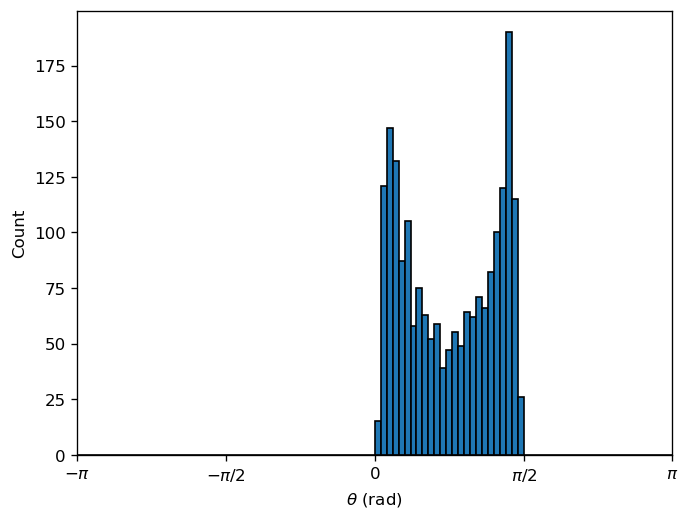

In [114]:
import numpy as np
import matplotlib.pyplot as plt

theta = np.asarray(theta)                       # radians

fig, ax = plt.subplots()
ax.hist(theta, bins=100, range=(-np.pi, np.pi), edgecolor='black')

ax.set_xlabel(r'$\theta$ (rad)')
ax.set_ylabel('Count')
ax.set_xlim(-np.pi, np.pi)
ax.set_xticks(np.arange(-np.pi, np.pi + 0.01, np.pi/2))
ax.set_xticklabels([r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
plt.show()

In [115]:
c1 = jnp.sum(pd["walkers"][0][:,0])
c2 = jnp.sum(pd["walkers"][0][:,1])
norm = jnp.sqrt(c1**2 + c2**2)
c1 = c1 / norm
c2 = c2 / norm
print(c1, c2)

(0.6979485420874711+0j) (0.7161479125138699+0j)


In [116]:
print(theta.max())
print(theta.min())

1.5412943864125035
0.04099816683394474


In [45]:
t0 = time.time()
DT, NSTEP, NBLK = 0.01, 10, 20

tau_fp, e_fp, err_fp = run_free_projection(
    ham_A, hamdata_A, trial_A, wave_A, nchol_A,
    dt=DT, n_walkers=200, n_prop_steps=NSTEP, n_blocks=NBLK, n_traj=5, seed=11)

# tau_ph, e_ph, err_ph, raw_ph, kill_ph = run_constrained(
#     propagator_uhf_gen, ham_A, hamdata_A, trial_A, wave_A, nchol_A,
#     dt=DT, n_walkers=200, n_prop_steps=NSTEP, n_blocks=NBLK, n_runs=3, seed=11)

tau_cp, e_cp, err_cp, raw_cp, kill_cp = run_constrained(
    propagator_cp, ham_A, hamdata_A, trial_A, wave_A, nchol_A,
    dt=DT, n_walkers=200, n_prop_steps=NSTEP, n_blocks=NBLK, n_runs=3, seed=11)

print("           tau      E(tau)          |E + t|")
for i in [0, NBLK // 2, NBLK - 1]:
    print(f"free proj  {tau_fp[i]:5.2f}  {e_fp[i]:+.12f}  {abs(e_fp[i]+T_HOP):.2e}")
    # print(f"phaseless  {tau_ph[i]:5.2f}  {e_ph[i]:+.12f}  {abs(e_ph[i]+T_HOP):.2e}")
    print(f"cons. path {tau_cp[i]:5.2f}  {e_cp[i]:+.12f}  {abs(e_cp[i]+T_HOP):.2e}")
    print()
# print("phaseless vs constrained path, max |difference| over all blocks and runs:",
#       np.max(np.abs(raw_ph - raw_cp)))
print(f"walkers killed by the constraint {kill_cp}")
print("elapsed %.1f s" % (time.time() - t0))

           tau      E(tau)          |E + t|
free proj   0.10  -1.000000000000  1.11e-16
cons. path  0.10  -1.000000000000  0.00e+00

free proj   1.10  -1.000000000000  0.00e+00
cons. path  1.10  -1.000000000000  0.00e+00

free proj   2.00  -1.000000000000  0.00e+00
cons. path  2.00  -1.000000000000  0.00e+00

walkers killed by the constraint 0
elapsed 2.0 s


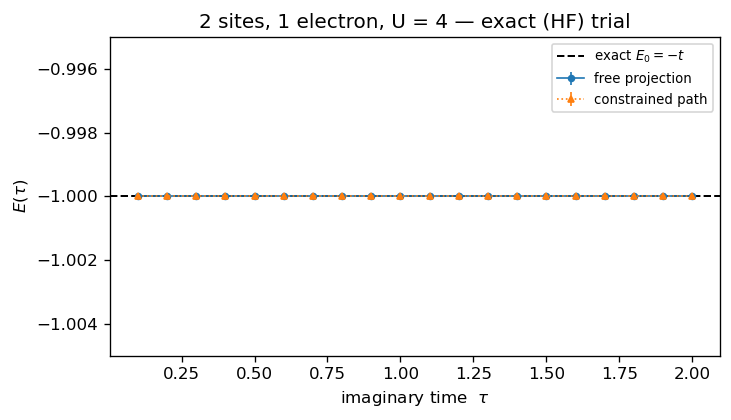

In [46]:
fig, ax = plt.subplots(figsize=(6.2, 3.6))
ax.axhline(-T_HOP, color="k", lw=1.2, ls="--", label=r"exact $E_0=-t$")
ax.errorbar(tau_fp, e_fp, err_fp, fmt="o-",  ms=3.5, lw=1, label="free projection")
ax.errorbar(tau_cp, e_cp, err_cp, fmt="^:",  ms=3.5, lw=1, label="constrained path")
ax.set_xlabel(r"imaginary time  $\tau$");  ax.set_ylabel(r"$E(\tau)$")
ax.set_title("2 sites, 1 electron, U = %g — exact (HF) trial" % U_INT)
ax.set_ylim(-1.0 - 5e-3, -1.0 + 5e-3)
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

Flat at $-t$ to $\sim10^{-16}$, and the phaseless and constrained-path trajectories are
**bit-for-bit identical** — with a real propagator the two weight updates are the same arithmetic.
No walker is ever killed, because the exact trial has no node the walkers can cross.

## 8. Seeing imaginary time actually do something: a deliberately bad trial

A flat line is reassuring but not very illuminating. To watch the projection work we keep the same
one-electron model but replace the trial by the *site-localised* determinant $|\Psi_T\rangle=|1\rangle$,
and start the walkers there as well. Then everything can be done by hand:

$$
|1\rangle=\tfrac{1}{\sqrt2}\big(|{\rm b}\rangle+|{\rm a}\rangle\big),\qquad
e^{-\tau\hat H}|1\rangle=\tfrac{1}{\sqrt2}\big(e^{+t\tau}|{\rm b}\rangle+e^{-t\tau}|{\rm a}\rangle\big),
$$

$$
\langle 1|e^{-\tau\hat H}|1\rangle=\cosh(t\tau),\qquad
\langle 1|\hat H e^{-\tau\hat H}|1\rangle=-t\sinh(t\tau),
$$

$$
\boxed{\;E_{\rm mix}(\tau)=-\,t\,\tanh(t\,\tau)\;}
$$

which starts at $E=0$ (the localised state has no kinetic energy) and decays to $-t$ with a rate
set by the gap $\Delta = E_{\rm a}-E_{\rm b}=2t$. Free projection is *exact*, so it must trace this
curve; the constrained methods must too, as long as the constraint never fires.

In [21]:
mo_local_a = np.array([[1.0], [0.0]])          # electron pinned to site 0
mo_local_b = np.zeros((N_SITES, 0))

ham_L, hamdata_L, nchol_L, trial_L, wave_L = afqmc_setup(
    h1_A, U_INT, NELEC_A, mo_local_a, mo_local_b, N_SITES)

DT, NSTEP, NBLK = 0.01, 10, 30

tau_fp_L, e_fp_L, err_fp_L = run_free_projection(
    ham_L, hamdata_L, trial_L, wave_L, nchol_L,
    dt=DT, n_walkers=500, n_prop_steps=NSTEP, n_blocks=NBLK, n_traj=16, seed=21)

tau_ph_L, e_ph_L, err_ph_L, raw_ph_L, kill_ph_L = run_constrained(
    propagator_uhf_gen, ham_L, hamdata_L, trial_L, wave_L, nchol_L,
    dt=DT, n_walkers=500, n_prop_steps=NSTEP, n_blocks=NBLK, n_runs=6, seed=21)

tau_cp_L, e_cp_L, err_cp_L, raw_cp_L, kill_cp_L = run_constrained(
    propagator_cp, ham_L, hamdata_L, trial_L, wave_L, nchol_L,
    dt=DT, n_walkers=500, n_prop_steps=NSTEP, n_blocks=NBLK, n_runs=6, seed=21)

e_exact_L = -T_HOP * np.tanh(T_HOP * tau_fp_L)

print("  tau     free proj            phaseless            cons. path        -t*tanh(t*tau)")
for i in range(0, NBLK, 4):
    print(f"{tau_fp_L[i]:5.2f}  {e_fp_L[i]:+.5f}+/-{err_fp_L[i]:.5f}   "
          f"{e_ph_L[i]:+.5f}+/-{err_ph_L[i]:.5f}   "
          f"{e_cp_L[i]:+.5f}+/-{err_cp_L[i]:.5f}   {e_exact_L[i]:+.5f}")
print("\nmax |phaseless - CP| =", np.max(np.abs(raw_ph_L - raw_cp_L)))
print("walkers killed by the constraint: phaseless %d, CP %d" % (kill_ph_L, kill_cp_L))

E0903 15:10:18.082174  821485 cuda_executor.cc:1213] [0] Failed to track device allocation: ALREADY_EXISTS: Allocation at address (nil) (size 0) is already tracked


  tau     free proj            phaseless            cons. path        -t*tanh(t*tau)
 0.10  -0.09885+/-0.00073   -0.09855+/-0.00101   -0.09855+/-0.00101   -0.09967
 0.50  -0.44482+/-0.00533   -0.47011+/-0.01463   -0.47011+/-0.01463   -0.46212
 0.90  -0.70007+/-0.01027   -0.67405+/-0.02175   -0.67405+/-0.02175   -0.71630
 1.30  -0.82393+/-0.01759   -0.78692+/-0.02962   -0.78692+/-0.02962   -0.86172
 1.70  -0.92574+/-0.01685   -0.92439+/-0.06367   -0.92439+/-0.06367   -0.93541
 2.10  -0.98718+/-0.01905   -0.91404+/-0.04362   -0.91404+/-0.04362   -0.97045
 2.50  -0.96695+/-0.02213   -0.92183+/-0.03805   -0.92183+/-0.03805   -0.98661
 2.90  -1.01656+/-0.02192   -0.93859+/-0.05725   -0.93859+/-0.05725   -0.99396

max |phaseless - CP| = 0.0
walkers killed by the constraint: phaseless 0, CP 0


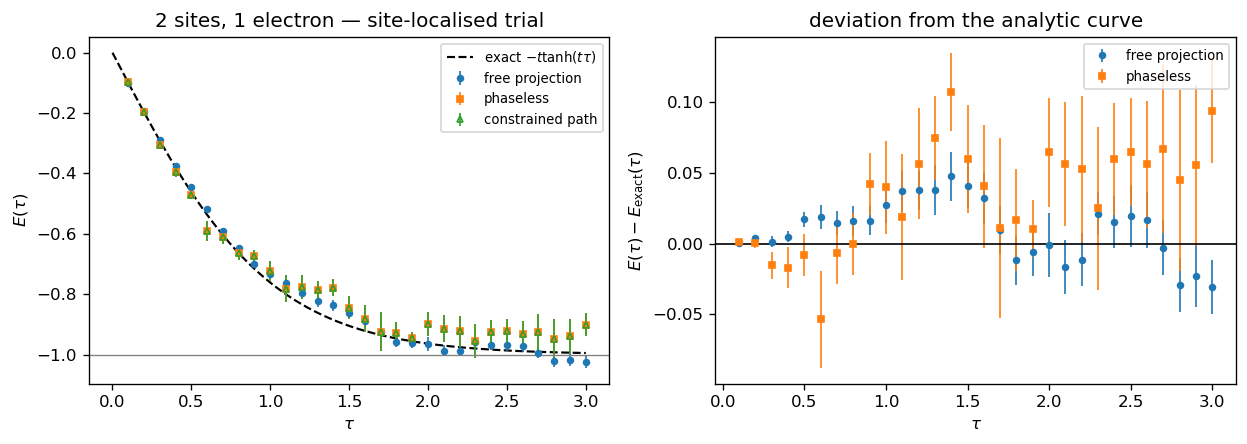

In [22]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(10.5, 3.8))

tt = np.linspace(0, tau_fp_L[-1], 400)
ax.plot(tt, -T_HOP*np.tanh(T_HOP*tt), "k--", lw=1.3, label=r"exact $-t\tanh(t\tau)$")
ax.errorbar(tau_fp_L, e_fp_L, err_fp_L, fmt="o",  ms=3.5, lw=1, label="free projection")
ax.errorbar(tau_ph_L, e_ph_L, err_ph_L, fmt="s",  ms=3.5, lw=1, label="phaseless")
ax.errorbar(tau_cp_L, e_cp_L, err_cp_L, fmt="^",  ms=3.5, lw=1, mfc="none", label="constrained path")
ax.axhline(-T_HOP, color="0.5", lw=0.8)
ax.set_xlabel(r"$\tau$"); ax.set_ylabel(r"$E(\tau)$")
ax.set_title("2 sites, 1 electron — site-localised trial")
ax.legend(fontsize=8)

ax2.errorbar(tau_fp_L, e_fp_L - e_exact_L, err_fp_L, fmt="o", ms=3.5, lw=1, label="free projection")
ax2.errorbar(tau_ph_L, e_ph_L - e_exact_L, err_ph_L, fmt="s", ms=3.5, lw=1, label="phaseless")
ax2.axhline(0, color="k", lw=1)
ax2.set_xlabel(r"$\tau$"); ax2.set_ylabel(r"$E(\tau)-E_{\rm exact}(\tau)$")
ax2.set_title("deviation from the analytic curve")
ax2.legend(fontsize=8)
fig.tight_layout(); plt.show()

Free projection follows $-t\tanh(t\tau)$ within the error bars over the whole trajectory — the
propagator, the HS transformation and the mixed estimator are all correct. The constrained methods
follow the same curve here because the constraint never triggers (no walker crosses the node of a
positive-definite one-electron trial).

Note that the free-projection error bar *grows* with $\tau$ even in this trivial problem: the
weights $W_w$ spread exponentially. That growth is the generic reason free projection is
unaffordable for large systems and why the constrained methods exist.

## 9. A genuinely correlated case: the half-filled dimer

Now put **two** electrons on the two sites, $n_\uparrow=n_\downarrow=1$, and switch $U$ on. In the
determinant basis $\{|{\uparrow\downarrow},0\rangle,|{\uparrow},{\downarrow}\rangle,
|{\downarrow},{\uparrow}\rangle,|0,{\uparrow\downarrow}\rangle\}$ the Hamiltonian is a $4\times4$
matrix whose singlet ground state is known analytically:

$$
E_0=\frac{U-\sqrt{U^{2}+16t^{2}}}{2}\;\xrightarrow[\;U=4t\;]{}\;2-2\sqrt2=-0.828427\ldots
$$

Neither RHF ($E=-2t+U/2=0$) nor the broken-symmetry UHF solution is exact, so the QMC has real
work to do. We use the UHF determinant as the trial and compare $E(\tau)$ with the **exact mixed
estimator** $\langle\Psi_T|\hat He^{-\tau\hat H}|\Psi_T\rangle/\langle\Psi_T|e^{-\tau\hat H}|\Psi_T\rangle$
computed by exact diagonalisation.

In [15]:
NELEC_B = (1, 1)
dm0_B = np.zeros((2, N_SITES, N_SITES))
dm0_B[0, 0, 0] = 1.0        # spin up on site 0
dm0_B[1, 1, 1] = 1.0        # spin down on site 1  (antiferromagnetic guess)

h1_B, eri_B, mol_B, mf_B = hubbard_mf(N_SITES, T_HOP, U_INT, NELEC_B, dm0=dm0_B)
e_fci_B = fci.direct_spin1.kernel(h1_B, eri_B, N_SITES, NELEC_B)[0]

print("E(UHF)            = %+.10f   <S^2> = %.4f" % (mf_B.e_tot, mf_B.spin_square()[0]))
print("E(FCI, pyscf)     = %+.10f" % e_fci_B)
print("E(analytic)       = %+.10f" % ((U_INT - np.sqrt(U_INT**2 + 16*T_HOP**2)) / 2))
print("correlation energy= %+.10f" % (e_fci_B - mf_B.e_tot))
print("\nUHF alpha orbital:", mf_B.mo_coeff[0][:, 0], "   beta orbital:", mf_B.mo_coeff[1][:, 0])

E(UHF)            = -0.5000000000   <S^2> = 0.7500
E(FCI, pyscf)     = -0.8284271247
E(analytic)       = -0.8284271247
correlation energy= -0.3284271247

UHF alpha orbital: [0.96592583 0.25881904]    beta orbital: [0.25881904 0.96592583]


In [16]:
ham_B, hamdata_B, nchol_B, trial_B, wave_B = afqmc_setup(
    h1_B, U_INT, NELEC_B, mf_B.mo_coeff[0][:, :1], mf_B.mo_coeff[1][:, :1], N_SITES)

DT, NSTEP, NBLK = 0.01, 20, 30      # tau up to 6
t0 = time.time()

tau_fp_B, e_fp_B, err_fp_B = run_free_projection(
    ham_B, hamdata_B, trial_B, wave_B, nchol_B,
    dt=DT, n_walkers=1000, n_prop_steps=NSTEP, n_blocks=NBLK, n_traj=16, seed=5)

tau_ph_B, e_ph_B, err_ph_B, raw_ph_B, kill_ph_B = run_constrained(
    propagator_uhf_gen, ham_B, hamdata_B, trial_B, wave_B, nchol_B,
    dt=DT, n_walkers=1000, n_prop_steps=NSTEP, n_blocks=NBLK, n_runs=6, seed=5)

tau_cp_B, e_cp_B, err_cp_B, raw_cp_B, kill_cp_B = run_constrained(
    propagator_cp, ham_B, hamdata_B, trial_B, wave_B, nchol_B,
    dt=DT, n_walkers=1000, n_prop_steps=NSTEP, n_blocks=NBLK, n_runs=6, seed=5)

H_B, to_ci_B = dimer_ci(T_HOP, U_INT, NELEC_B)
v_T = to_ci_B(mf_B.mo_coeff[0][:, :1], mf_B.mo_coeff[1][:, :1])
e_mix_B = exact_mixed_estimator(H_B, v_T, v_T, tau_fp_B)

print("  tau     free proj             phaseless            cons. path       exact mixed")
for i in range(0, NBLK, 3):
    print(f"{tau_fp_B[i]:5.2f}  {e_fp_B[i]:+.5f}+/-{err_fp_B[i]:.5f}   "
          f"{e_ph_B[i]:+.5f}+/-{err_ph_B[i]:.5f}   "
          f"{e_cp_B[i]:+.5f}+/-{err_cp_B[i]:.5f}   {e_mix_B[i]:+.5f}")
print("\nmax |phaseless - CP| =", np.max(np.abs(raw_ph_B - raw_cp_B)))
print("elapsed %.1f s" % (time.time() - t0))

  tau     free proj             phaseless            cons. path       exact mixed
 0.20  -0.54227+/-0.00137   -0.54460+/-0.00328   -0.54460+/-0.00328   -0.54249
 0.80  -0.62224+/-0.00639   -0.62715+/-0.01396   -0.62715+/-0.01396   -0.63176
 1.40  -0.68347+/-0.00831   -0.68308+/-0.00512   -0.68308+/-0.00512   -0.69669
 2.00  -0.71620+/-0.00853   -0.71519+/-0.01391   -0.71519+/-0.01391   -0.74297
 2.60  -0.75850+/-0.01056   -0.75889+/-0.01954   -0.75889+/-0.01954   -0.77425
 3.20  -0.79249+/-0.01222   -0.77681+/-0.01755   -0.77681+/-0.01755   -0.79461
 3.80  -0.80195+/-0.01332   -0.82627+/-0.01889   -0.82627+/-0.01889   -0.80752
 4.40  -0.80584+/-0.01310   -0.80747+/-0.02173   -0.80747+/-0.02173   -0.81558
 5.00  -0.82096+/-0.01351   -0.81270+/-0.01641   -0.81270+/-0.01641   -0.82056
 5.60  -0.82796+/-0.01743   -0.82068+/-0.00850   -0.82068+/-0.00850   -0.82363

max |phaseless - CP| = 0.0
elapsed 22.8 s


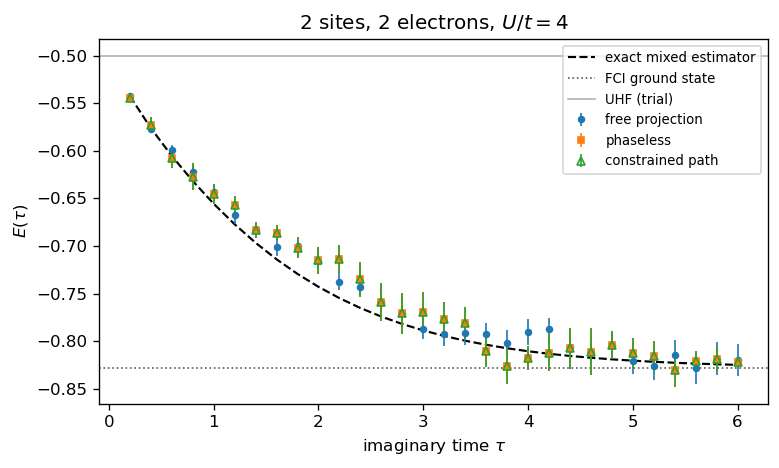

In [17]:
fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(tau_fp_B, e_mix_B, "k--", lw=1.3, label=r"exact mixed estimator")
ax.axhline(e_fci_B, color="0.35", lw=1.0, ls=":", label="FCI ground state")
ax.axhline(mf_B.e_tot, color="0.7", lw=1.0, ls="-", label="UHF (trial)")
ax.errorbar(tau_fp_B, e_fp_B, err_fp_B, fmt="o", ms=3.5, lw=1, label="free projection")
ax.errorbar(tau_ph_B, e_ph_B, err_ph_B, fmt="s", ms=3.5, lw=1, label="phaseless")
ax.errorbar(tau_cp_B, e_cp_B, err_cp_B, fmt="^", ms=4.5, lw=1, mfc="none", label="constrained path")
ax.set_xlabel(r"imaginary time $\tau$"); ax.set_ylabel(r"$E(\tau)$")
ax.set_title(r"2 sites, 2 electrons, $U/t=%g$" % (U_INT / T_HOP))
ax.legend(fontsize=8, loc="upper right"); fig.tight_layout(); plt.show()

In [18]:
# long constrained-path run to read off the converged (plateau) energy
DT, NSTEP, NBLK = 0.01, 20, 120
t0 = time.time()
_, _, _, raw_long, kill_long = run_constrained(
    propagator_cp, ham_B, hamdata_B, trial_B, wave_B, nchol_B,
    dt=DT, n_walkers=1000, n_prop_steps=NSTEP, n_blocks=NBLK, n_runs=12, seed=101)

mean, err = plateau_estimate(raw_long)              # discard tau < 12 as equilibration
naive_err = raw_long[:, NBLK // 2:].ravel().std(ddof=1) / np.sqrt(raw_long[:, NBLK // 2:].size)

print("CP / phaseless plateau  E = %+.5f +/- %.5f   (12 independent trajectories)" % (mean, err))
print("FCI                     E = %+.5f" % e_fci_B)
print("difference                %+.5f   (%.1f sigma)" % (mean - e_fci_B, abs(mean - e_fci_B) / err))
print()
print("naive per-block error bar : %.5f  -> %.1fx too small; block energies within one"
      % (naive_err, err / naive_err))
print("trajectory are strongly autocorrelated, so they are not independent samples.")
print("walkers killed by the constraint over the whole run:", kill_long)
print("elapsed %.1f s" % (time.time() - t0))

CP / phaseless plateau  E = -0.83081 +/- 0.00674   (12 independent trajectories)
FCI                     E = -0.82843
difference                -0.00238   (0.4 sigma)

naive per-block error bar : 0.00179  -> 3.8x too small; block energies within one
trajectory are strongly autocorrelated, so they are not independent samples.
walkers killed by the constraint over the whole run: 0
elapsed 19.4 s


The QMC recovers essentially all of the correlation energy: from $E_{\rm UHF}=-0.5$ to
$\simeq-0.83$ against $E_{\rm FCI}=-0.828427$. Free projection tracks the exact mixed estimator
curve, and the constrained runs reach the same plateau within their (trajectory-based) error bar.

On a system this small the constraint is **never actually active** — not one walker is killed —
so free projection, phaseless and constrained path are all sampling the same, unbiased
projection, and the only systematics left are the Trotter error and population-control bias.
The differences between the three algorithms only appear once the sign problem is severe enough
to push walkers across the node of the trial.

## 10. Why phaseless $\equiv$ constrained path here

The claim of section 5 was: with the spin decomposition the propagator is real, therefore
$I\in\mathbb R$, therefore $|I|\cos\theta=\mathrm{Re}\,I$. Let us verify each link directly by
instrumenting a single propagation step on an equilibrated walker population, and comparing the
spin decomposition against the charge decomposition.

In [19]:
def phase_diagnostics(ham, ham_data, trial, wave_data, nchol,
                      dt=0.01, n_walkers=500, n_prop_steps=200, n_eq_blocks=8, seed=1):
    "Equilibrate, then take one instrumented step and look at the importance function I."
    prop = propagator_uhf_gen(dt=dt, n_walkers=n_walkers, n_exp_terms=10, n_batch=1)
    hd   = ham.build_propagation_intermediates(dict(ham_data), prop, trial, wave_data)
    pd   = prop.init_prop_data(trial, wave_data, hd, None)
    pd["key"] = random.PRNGKey(seed); pd["n_killed_walkers"] = 0

    smp = sampling.sampler(n_prop_steps=n_prop_steps, n_blocks=1, n_chol=nchol)
    for _ in range(n_eq_blocks):
        pd, _ = smp.block_sample(pd, hd, prop, trial, wave_data)

    key, sub = random.split(pd["key"])
    fields = random.normal(sub, (n_walkers, nchol))

    fb  = trial.calc_force_bias(pd["walkers"], hd, wave_data)
    fs  = -jnp.sqrt(dt) * (1.0j * fb - hd["mf_shifts"])
    sf  = fields - fs
    st  = jnp.sum(sf * hd["mf_shifts"], axis=1)
    fbt = jnp.sum(fields * fs - fs * fs / 2.0, axis=1)

    w_new = prop._apply_trotprop(hd, [w for w in pd["walkers"]], sf)
    o_new = trial.calc_overlap(w_new, wave_data)
    I = jnp.exp(-jnp.sqrt(dt) * st + fbt
                + dt * (pd["pop_control_ene_shift"] + hd["h0_prop"])) * o_new / pd["overlaps"]

    theta = jnp.angle(jnp.exp(-jnp.sqrt(dt) * st) * o_new / pd["overlaps"])
    w_phaseless = jnp.abs(I) * jnp.cos(theta)
    w_cp        = jnp.real(I)

    return dict(
        max_im_walker = float(jnp.max(jnp.abs(jnp.imag(pd["walkers"][0])))),
        max_rel_im_I  = float(jnp.max(jnp.abs(jnp.imag(I)) / jnp.abs(I))),
        max_ph_minus_cp = float(jnp.max(jnp.abs(w_phaseless - w_cp))),
        frac_negative = float(jnp.mean(jnp.real(I) < 0.0)),
    )


for label, dec in [("spin  ", "spin"), ("charge", "charge")]:
    hamX, hdX, nchX, trX, wdX = afqmc_setup(
        h1_B, U_INT, NELEC_B, mf_B.mo_coeff[0][:, :1], mf_B.mo_coeff[1][:, :1],
        N_SITES, decomposition=dec)
    d = phase_diagnostics(hamX, hdX, trX, wdX, nchX)
    print(f"{label} decomposition:  max|Im(walker)| = {d['max_im_walker']:.2e}   "
          f"max|Im I|/|I| = {d['max_rel_im_I']:.2e}   "
          f"max|phaseless - CP| = {d['max_ph_minus_cp']:.2e}   "
          f"fraction Re(I)<0 = {d['frac_negative']:.4f}")

spin   decomposition:  max|Im(walker)| = 0.00e+00   max|Im I|/|I| = 0.00e+00   max|phaseless - CP| = 0.00e+00   fraction Re(I)<0 = 0.0000
charge decomposition:  max|Im(walker)| = 7.07e-01   max|Im I|/|I| = 3.23e-08   max|phaseless - CP| = 5.55e-16   fraction Re(I)<0 = 0.0000


With the **spin** decomposition the walkers stay real to the last bit, $\mathrm{Im}\,I=0$ *exactly*,
and the phaseless and constrained-path weight updates are identical to the last bit. There is no
phase to lose — only the sign of $\langle\Psi_T|\phi\rangle$, which is what the constrained-path
condition controls.

With the **charge** decomposition the walkers do become genuinely complex
($\max|\mathrm{Im}\,\phi|\sim0.7$), which is the phase problem in the making. For the *repulsive*
Hubbard model with a real trial the residual phase of $I$ after the force-bias shift still happens
to be tiny, so the two constraints remain numerically very close here; the point is that with the
spin decomposition the cancellation is exact by construction rather than accidental.

**Practical conclusion:** for the Hubbard model always use the spin decomposition. Then
"phaseless AFQMC" and "constrained-path AFQMC" are the same calculation.

## 11. Turning on the sign problem: a 4-site chain

Two sites are too small for the constraint to matter. A half-filled 4-site chain at $U/t=4$ has a
substantial correlation energy ($E_{\rm UHF}=-1.434$ vs $E_{\rm FCI}=-1.953$) and lets us watch
$E(\tau)$ fall from the mean field all the way to FCI. It also shows where the statistical cost
comes from: the free-projection error bar grows by an order of magnitude over the first few units
of imaginary time before the per-step stochastic reconfiguration caps it. At larger $N_s$ that
growth is what becomes uncontrollable — it is the sign problem — and is the reason one accepts the
constraint at all.

In [20]:
N4, NELEC_C = 4, (2, 2)
dm0_C = np.zeros((2, N4, N4))
for i in range(N4):
    dm0_C[i % 2, i, i] = 1.0                       # Neel-like starting guess

h1_C, eri_C, mol_C, mf_C = hubbard_mf(N4, T_HOP, U_INT, NELEC_C, dm0=dm0_C)
e_fci_C = fci.direct_spin1.kernel(h1_C, eri_C, N4, NELEC_C)[0]
print("E(UHF) = %+.8f    E(FCI) = %+.8f    E_corr = %+.8f"
      % (mf_C.e_tot, e_fci_C, e_fci_C - mf_C.e_tot))

ham_C, hamdata_C, nchol_C, trial_C, wave_C = afqmc_setup(
    h1_C, U_INT, NELEC_C, mf_C.mo_coeff[0][:, :2], mf_C.mo_coeff[1][:, :2], N4)

DT, NSTEP, NBLK = 0.01, 20, 40                     # tau up to 8
t0 = time.time()
tau_fp_C, e_fp_C, err_fp_C = run_free_projection(
    ham_C, hamdata_C, trial_C, wave_C, nchol_C,
    dt=DT, n_walkers=1000, n_prop_steps=NSTEP, n_blocks=NBLK, n_traj=12, seed=7)
tau_ph_C, e_ph_C, err_ph_C, raw_ph_C, kill_ph_C = run_constrained(
    propagator_uhf_gen, ham_C, hamdata_C, trial_C, wave_C, nchol_C,
    dt=DT, n_walkers=1000, n_prop_steps=NSTEP, n_blocks=NBLK, n_runs=8, seed=7)
tau_cp_C, e_cp_C, err_cp_C, raw_cp_C, kill_cp_C = run_constrained(
    propagator_cp, ham_C, hamdata_C, trial_C, wave_C, nchol_C,
    dt=DT, n_walkers=1000, n_prop_steps=NSTEP, n_blocks=NBLK, n_runs=8, seed=7)
print("elapsed %.1f s" % (time.time() - t0))
print("max |phaseless - CP| =", np.max(np.abs(raw_ph_C - raw_cp_C)))

for name, raw, err in [("phaseless ", raw_ph_C, err_ph_C),
                       ("cons. path", raw_cp_C, err_cp_C)]:
    m, s = plateau_estimate(raw)
    print("%s  plateau E = %+.5f +/- %.5f   (error bar at tau=%.1f : %.4f)"
          % (name, m, s, tau_fp_C[-1], err[-1]))
print("free proj   E(tau=%.1f) = %+.5f +/- %.5f   (still decaying -- see the plot)"
      % (tau_fp_C[-1], e_fp_C[-1], err_fp_C[-1]))
print("FCI                    %+.5f" % e_fci_C)

E(UHF) = -1.43432125    E(FCI) = -1.95314531    E_corr = -0.51882405
elapsed 31.8 s
max |phaseless - CP| = 0.0
phaseless   plateau E = -1.94112 +/- 0.01494   (error bar at tau=8.0 : 0.0207)
cons. path  plateau E = -1.94112 +/- 0.01494   (error bar at tau=8.0 : 0.0207)
free proj   E(tau=8.0) = -1.95187 +/- 0.02459   (still decaying -- see the plot)
FCI                    -1.95315


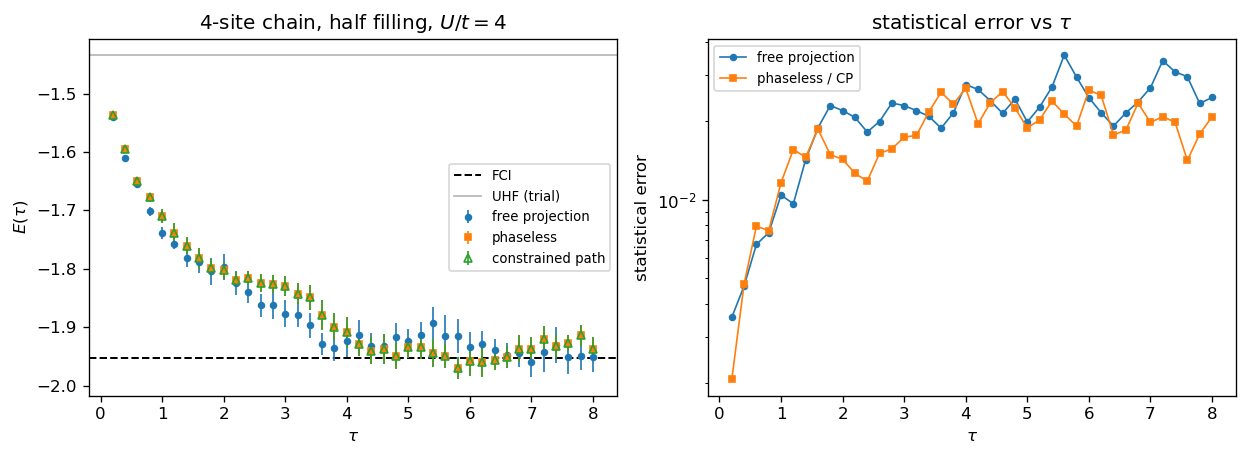

In [21]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(10.5, 3.9))
ax.axhline(e_fci_C, color="k", ls="--", lw=1.2, label="FCI")
ax.axhline(mf_C.e_tot, color="0.7", lw=1.0, label="UHF (trial)")
ax.errorbar(tau_fp_C, e_fp_C, err_fp_C, fmt="o", ms=3.5, lw=1, label="free projection")
ax.errorbar(tau_ph_C, e_ph_C, err_ph_C, fmt="s", ms=3.5, lw=1, label="phaseless")
ax.errorbar(tau_cp_C, e_cp_C, err_cp_C, fmt="^", ms=4.5, lw=1, mfc="none", label="constrained path")
ax.set_xlabel(r"$\tau$"); ax.set_ylabel(r"$E(\tau)$")
ax.set_title(r"4-site chain, half filling, $U/t=%g$" % (U_INT/T_HOP))
ax.legend(fontsize=8)

ax2.semilogy(tau_fp_C, err_fp_C, "o-", ms=3.5, lw=1, label="free projection")
ax2.semilogy(tau_ph_C, err_ph_C, "s-", ms=3.5, lw=1, label="phaseless / CP")
ax2.set_xlabel(r"$\tau$"); ax2.set_ylabel("statistical error")
ax2.set_title(r"statistical error vs $\tau$")
ax2.legend(fontsize=8)
fig.tight_layout(); plt.show()

All three methods converge onto FCI: the free projection reaches
$E(\tau\!=\!8)=-1.952(25)$ against $E_{\rm FCI}=-1.95315$, and phaseless / constrained path
plateau at $-1.941(15)$ — again identical to each other bit for bit.

The right panel shows the statistical error. Both grow by roughly an order of magnitude during
the first $\tau\sim2$ and then saturate, because `fp_sampler` reconfigures the population at
*every* time step, which caps the weight spread. Four sites is still far too small for the sign
problem to be fatal — the constraint fires so rarely that free projection remains affordable. At
larger $N_s$ the free-projection variance grows exponentially in $\tau$ and in system size, and
the constrained methods become the only option; their price is a small, uncontrolled bias set by
the nodal structure of the trial.

## 12. Cross-check with `trot`: discrete-HS constrained-path Monte Carlo

Everything above uses *continuous* auxiliary fields, which is what generic ab-initio AFQMC does.
For the Hubbard model the textbook algorithm (Zhang–Carlson–Gubernatis CPMC) instead uses the
**discrete** Hirsch transformation

$$
e^{-\Delta\tau U \hat n_{i\uparrow}\hat n_{i\downarrow}}
=e^{-\frac{\Delta\tau U}{2}(\hat n_{i\uparrow}+\hat n_{i\downarrow})}\,
\frac12\!\!\sum_{s_i=\pm1}\! e^{\,\gamma\, s_i(\hat n_{i\uparrow}-\hat n_{i\downarrow})},
\qquad
\cosh\gamma=e^{\Delta\tau U/2},
$$

which is *exact* at each time step (no field integral to discretise), with only two field values
per site. `afqmc` ships a `propagation.propagator_cpmc`, but it calls trial methods
(`calc_full_green_vmap`, `calc_overlap_ratio_vmap`, `update_greens_function_vmap`) that do not
exist in `afqmc/wavefunctions/` — so it cannot be run as is. **`trot`** has the complete
implementation (`trot/prop/cpmc.py`, `trot/prop/hubbard_cpmc_ops.py`,
`trot/trial/multi_ghf.py`, `trot/meas/multi_ghf.py`), including the rank-2 Sherman–Morrison
Green's-function updates. We use it as an independent check of the numbers above.

The trial is expressed as a (single-determinant) **GHF** ket of shape $(2N_s, N_e)$ built
block-diagonally from the PySCF $\alpha$ and $\beta$ orbitals.

In [22]:
from trot.core.system import System
from trot.ham.hubbard import HamHubbard
from trot.trial.multi_ghf import MultiGhfTrial, make_multi_ghf_trial_ops
from trot.meas.multi_ghf import make_multi_ghf_meas_ops_hubbard
from trot.prop.types import QmcParams
from trot.prop import cpmc as trot_cpmc
from trot.prop import blocks as trot_blocks


def run_trot_cpmc(h1, u, nelec, mo_a, mo_b, n_sites,
                  dt=0.01, n_walkers=500, n_prop_steps=20, n_blocks=40, seed=3):
    "Discrete-HS constrained-path QMC using trot.  Returns tau, E(tau), node encounters."
    # These lattices are tiny (2-4 sites); per-kernel GPU dispatch overhead dominates and
    # `trot_blocks.block` re-traces its lax.scan on every call.  Running trot on the CPU
    # backend is ~3x faster here.  (afqmc above stays on whatever setup_jax picked.)
    cpu = jax.devices("cpu")[0]

    sys_ = System(norb=n_sites, nelec=tuple(nelec), walker_kind="unrestricted")
    ham  = HamHubbard(h1=jnp.array(h1), u=float(u))

    nup, ndn = nelec
    C = np.zeros((2 * n_sites, nup + ndn))
    C[:n_sites, :nup] = mo_a
    C[n_sites:, nup:] = mo_b
    trial_data = MultiGhfTrial(
        ci_coeffs=jnp.array([1.0 + 0.0j]),
        mo_coeffs=jnp.array(C)[None] + 0.0j,
        green_real_dtype=jnp.float64, green_complex_dtype=jnp.complex128)

    trial_ops = make_multi_ghf_trial_ops(sys_)
    meas_ops  = make_multi_ghf_meas_ops_hubbard(sys_)
    params    = QmcParams(dt=dt, n_walkers=n_walkers,
                          n_prop_steps=n_prop_steps, n_blocks=n_blocks, seed=seed)

    prop_ops = trot_cpmc.make_prop_ops(ham, "unrestricted", trial_ops)
    prop_ctx = prop_ops.build_prop_ctx(ham, trial_data, params)
    meas_ctx = meas_ops.build_meas_ctx(ham, trial_data)

    with jax.default_device(cpu):
        state = prop_ops.init_prop_state(sys=sys_, ham_data=ham, trial_ops=trial_ops,
                                         trial_data=trial_data, meas_ops=meas_ops, params=params)
        e_blocks = []
        for _ in range(n_blocks):
            state, obs = trot_blocks.block(
                state, sys=sys_, params=params, ham_data=ham, trial_data=trial_data,
                trial_ops=trial_ops, meas_ops=meas_ops, meas_ctx=meas_ctx,
                prop_ops=prop_ops, prop_ctx=prop_ctx)
            e_blocks.append(float(obs.scalars["energy"]))
    tau = dt * n_prop_steps * np.arange(1, n_blocks + 1)
    return tau, np.array(e_blocks), int(state.node_encounters)

In [23]:
def trot_cpmc_traj(h1, u, nelec, mo_a, mo_b, n_sites, seeds, **kw):
    "Run several independent trot CPMC trajectories; return tau, (n_seeds, n_blocks) energies."
    rows, nodes = [], 0
    for sd in seeds:
        tau, e, nd = run_trot_cpmc(h1, u, nelec, mo_a, mo_b, n_sites, seed=int(sd), **kw)
        rows.append(e); nodes += nd
    return tau, np.array(rows), nodes


t0 = time.time()

# (a) the minimal example: 1 electron on 2 sites -> must be exactly -t
tau_a, e_a, nodes_a = run_trot_cpmc(
    h1_A, U_INT, NELEC_A, mf_A.mo_coeff[0][:, :1], np.zeros((N_SITES, 0)), N_SITES,
    dt=0.01, n_walkers=200, n_prop_steps=10, n_blocks=20, seed=3)
print("1 electron / 2 sites : E = %+.12f (max deviation from -t: %.2e), node encounters %d"
      % (e_a.mean(), np.max(np.abs(e_a + T_HOP)), nodes_a))

# (b) the half-filled dimer
tau_b, raw_b, nodes_b = trot_cpmc_traj(
    h1_B, U_INT, NELEC_B, mf_B.mo_coeff[0][:, :1], mf_B.mo_coeff[1][:, :1], N_SITES,
    seeds=range(1, 7), dt=0.01, n_walkers=1000, n_prop_steps=20, n_blocks=60)
e_b = raw_b.mean(axis=0)
m_b, s_b = plateau_estimate(raw_b)
print("2 electrons / 2 sites: E = %+.5f +/- %.5f   (FCI %+.5f)   node encounters %d"
      % (m_b, s_b, e_fci_B, nodes_b))

# (c) the 4-site chain
tau_c, raw_c, nodes_c = trot_cpmc_traj(
    h1_C, U_INT, NELEC_C, mf_C.mo_coeff[0][:, :2], mf_C.mo_coeff[1][:, :2], N4,
    seeds=range(1, 7), dt=0.01, n_walkers=1000, n_prop_steps=20, n_blocks=60)
e_c = raw_c.mean(axis=0)
m_c, s_c = plateau_estimate(raw_c)
print("4 electrons / 4 sites: E = %+.5f +/- %.5f   (FCI %+.5f)   node encounters %d"
      % (m_c, s_c, e_fci_C, nodes_c))
print("elapsed %.1f s" % (time.time() - t0))

1 electron / 2 sites : E = -1.000000000000 (max deviation from -t: 3.33e-16), node encounters 0
2 electrons / 2 sites: E = -0.82538 +/- 0.01051   (FCI -0.82843)   node encounters 0
4 electrons / 4 sites: E = -1.96103 +/- 0.02072   (FCI -1.95315)   node encounters 0
elapsed 305.6 s


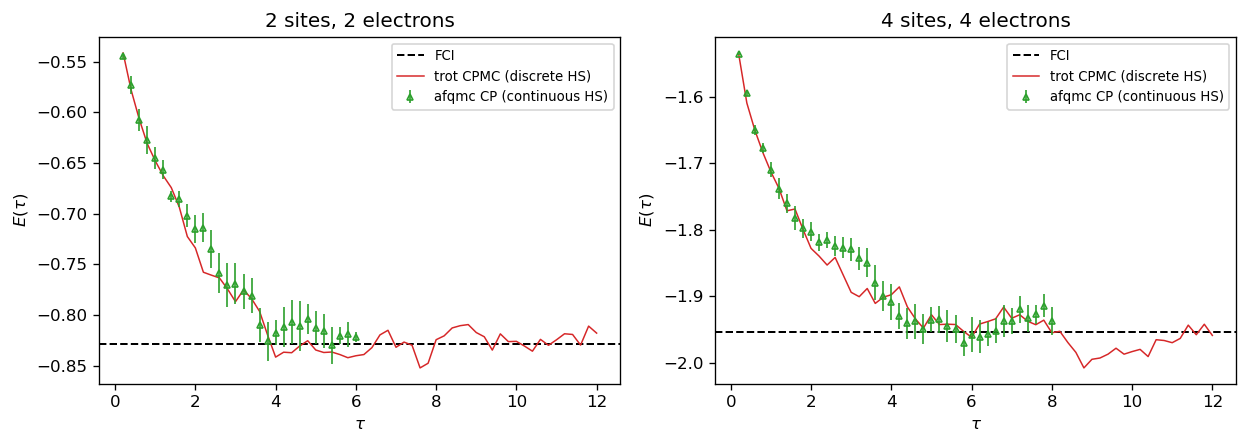

In [24]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.5, 3.8))
a1.axhline(e_fci_B, color="k", ls="--", lw=1.2, label="FCI")
a1.plot(tau_b, e_b, "-", lw=0.9, color="C3", label="trot CPMC (discrete HS)")
a1.errorbar(tau_cp_B, e_cp_B, err_cp_B, fmt="^", ms=4, lw=1, color="C2",
            mfc="none", label="afqmc CP (continuous HS)")
a1.set_xlabel(r"$\tau$"); a1.set_ylabel(r"$E(\tau)$"); a1.set_title("2 sites, 2 electrons")
a1.legend(fontsize=8)

a2.axhline(e_fci_C, color="k", ls="--", lw=1.2, label="FCI")
a2.plot(tau_c, e_c, "-", lw=0.9, color="C3", label="trot CPMC (discrete HS)")
a2.errorbar(tau_cp_C, e_cp_C, err_cp_C, fmt="^", ms=4, lw=1, color="C2",
            mfc="none", label="afqmc CP (continuous HS)")
a2.set_xlabel(r"$\tau$"); a2.set_ylabel(r"$E(\tau)$"); a2.set_title("4 sites, 4 electrons")
a2.legend(fontsize=8)
fig.tight_layout(); plt.show()

The two independent implementations — continuous-field constrained path in `afqmc` and
discrete-field CPMC in `trot` — agree with each other and with FCI. Note that the discrete
Hirsch transformation removes the field-integral discretisation entirely (only the Trotter error
remains), which is why CPMC is the method of choice for lattice models, while the continuous
decomposition is what makes AFQMC applicable to general ab-initio Hamiltonians.

## 13. Summary

**What was done**

1. The Hubbard model was fed to PySCF by overriding `get_hcore`, `get_ovlp` and `_eri`; UHF on
   two sites with one electron reproduces the exact $E_0=-t$.
2. The on-site repulsion was factorised for AFQMC with the **spin (Hirsch) decomposition**,
   $L^\gamma_{\uparrow/\downarrow}=\mp i\sqrt U\,|\gamma\rangle\langle\gamma|$, which makes the
   auxiliary-field propagator real. Spin-dependent Cholesky vectors are supported natively by
   `afqmc` (`ham_data["chol"]` is a per-spin tuple).
3. Three propagators were run and compared as a function of imaginary time:
   * **free projection** — no constraint, exact, error bars that grow with $\tau$;
   * **phaseless** — `afqmc`'s standard `propagate`;
   * **constrained path** — a 10-line subclass replacing $|I|\cos\theta$ by $\max(0,\mathrm{Re}\,I)$.

**Physics conclusions**

| system | trial | exact | AFQMC |
|---|---|---|---|
| 2 sites, 1 e | HF (exact) | $-1$ | all three flat at $-1$, error $\sim10^{-16}$ |
| 2 sites, 1 e | site-localised | $-t\tanh(t\tau)$ | free projection reproduces the analytic curve |
| 2 sites, 2 e, $U=4t$ | UHF | $-0.828427$ | FP tracks the exact mixed estimator; CP plateau $-0.8308(67)$ |
| 4 sites, 4 e, $U=4t$ | UHF | $-1.953145$ | FP $-1.952(25)$ at $\tau=8$; CP plateau $-1.941(15)$ |
| `trot` CPMC (discrete HS) | UHF/GHF | — | dimer $-0.8254(105)$, 4-site $-1.961(21)$ |

* **Phaseless = constrained path** for the Hubbard model, exactly, provided the spin decomposition
  is used: the importance function is real, so $|I|\cos\theta$ and $\mathrm{Re}\,I$ are the same
  number. This was verified bit-for-bit, not just statistically.
* With the charge decomposition the walkers become complex — that is the phase problem — even
  though for this repulsive real-trial model the residual phase of $I$ stays tiny.
* Free projection is exact but its variance grows with $\tau$ (exponentially, once the system is
  large enough); the constraint trades that for a small bias controlled by the trial. On the
  lattices used here the constraint is never active — no walker is killed — which is why all
  three methods agree.
* Block energies inside one trajectory are strongly autocorrelated. Averaging **independent
  trajectories** (rather than blocks) is what gives an honest error bar: the naive per-block
  standard error is ~4x too small here, which would have made a perfectly good result look like a
  2-3 sigma discrepancy.

**Notes on the codes**

* `afqmc.propagation.propagator_unrestricted.propagate_free` and `fp_sampling.fp_sampler._step_scan`
  divide by `2*nelec[sigma]`, which fails for a fully polarised system ($n_\beta = 0$). The
  subclasses here spread the phase over all $N_e$ occupied columns instead — equivalent when both
  channels are occupied, and well defined when one is empty.
* `propagate_free` also computes `exp(dt*h0_prop + e_estimate)` where `exp(dt*(h0_prop + e_estimate))`
  is meant. It is a walker-independent factor that cancels in the estimator (the weights are
  renormalised every step), but it can overflow; fixed in the subclass.
* `afqmc.propagation.propagator_cpmc` cannot currently run: it requires
  `calc_full_green_vmap`, `calc_overlap_ratio_vmap` and `update_greens_function_vmap` on the trial,
  none of which exist in `afqmc/wavefunctions/`. `trot` has a working equivalent
  (`trot/prop/cpmc.py` + `trot/trial/multi_ghf.py`), used in section 12.